In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
SRC = PROJECT_ROOT / 'src'

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from credit_default.utils import (
    load_checkpoint,
    get_models_and_routes
)

from credit_default.modeling.optimization import best_params

from credit_default.modeling.pipelines import (
    
    build_logistic_regression_pipeline_np1log_optimized
)

from credit_default.evaluation import (
    score_modelo_no_lineal,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    frame_data
)

import matplotlib.pyplot as plt

from credit_default.utils import save_model_joblib

In [2]:
checkpoint_path = PROJECT_ROOT / 'checkpoints' / 'vif_checkpoint'

model_list, nombre_modelos = get_models_and_routes(PROJECT_ROOT) ## Podríamos tener función para modelo elegido.

arreglo_frames, metadata_json = load_checkpoint(checkpoint_path)

X_train, X_test, y_train, y_test = arreglo_frames

Preparando modelos ... /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit
Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/models/logistic_np1log/lr_np1log.joblib 

Modelo cargado lr_np1log.joblib. 

Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/models/xgboost/xgboost_base.joblib 

Modelo cargado xgboost_base.joblib. 

Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/models/logistic_simple/lr_raw.joblib 

Modelo cargado lr_raw.joblib. 

----- Todos los modelos han sido cargados -----
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/X_train.parquet
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/X_test.parquet
Cargando el archivo /Users/ma

In [3]:
nombre_modelos

['lr_np1log.joblib', 'xgboost_base.joblib', 'lr_raw.joblib']

In [4]:
metadata_json ## Metadata ya viene cortada por VIF, importante

{'nombre_df': 'vif_checkpoint',
 'columnas_log1p': ['BILL_AMT_std', 'PAY_AMT_mean', 'payment_to_debt'],
 'columnas_numericas': ['debt_to_limit', 'LIMIT_BAL', 'AGE'],
 'columnas_categoricas': ['SEX',
  'EDUCATION',
  'MARRIAGE_CLEAN',
  'PAY_0',
  'PAY_2',
  'PAY_3',
  'PAY_4',
  'PAY_5',
  'PAY_6'],
 'columnas_yeo': []}

In [5]:
proposed = 'lr_np1log.joblib'
proposed_index = nombre_modelos.index(proposed)
modelo_propuesto = model_list[proposed_index]

In [6]:
modelo_propuesto

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log1p_num', ...), ('yeo', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [7]:
## El Penalty and l1_ratio sera deprecado de sickit-learn, no lo usremos.
mode = 'balanced_accuracy'
fold = 5
params = {
    'model__C' : [0.1, 0.4, 0.8, 1, 2, 5],
    'model__class_weight' : [None, 'balanced'] ## importante dado el desbalance
}

In [8]:
CLF = best_params(modelo_propuesto, params, X_train, y_train, mode, fold)

In [9]:
reg_log_cv_resultados = pd.DataFrame(CLF.cv_results_)
(
    reg_log_cv_resultados[['params', 'mean_test_score', 'std_test_score']]
    .sort_values(by = 'mean_test_score', ascending = False)
    .head(10)
)

,params,mean_test_score,std_test_score
1,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.708397,0.005617
3,"{'model__C': 0.4, 'model__class_weight': 'bala...",0.707983,0.005251
7,"{'model__C': 1, 'model__class_weight': 'balanc...",0.707780,0.004745
9,"{'model__C': 2, 'model__class_weight': 'balanc...",0.707780,0.004846
5,"{'model__C': 0.8, 'model__class_weight': 'bala...",0.707687,0.005123
11,"{'model__C': 5, 'model__class_weight': 'balanc...",0.707390,0.005091
2,"{'model__C': 0.4, 'model__class_weight': None}",0.654728,0.001119
4,"{'model__C': 0.8, 'model__class_weight': None}",0.654676,0.001055
8,"{'model__C': 2, 'model__class_weight': None}",0.654676,0.001072
6,"{'model__C': 1, 'model__class_weight': None}",0.654515,0.000877


In [10]:
CLF.best_params_

{'model__C': 0.1, 'model__class_weight': 'balanced'}

In [11]:
metadata_json
cols_to_log1p = metadata_json['columnas_log1p']
cols_to_numeric = metadata_json['columnas_numericas']
cols_to_yeo = metadata_json['columnas_yeo']
categorical_cols = metadata_json['columnas_categoricas']
C_optimized = CLF.best_params_['model__C']

In [12]:
final_pipeline = build_logistic_regression_pipeline_np1log_optimized(
    cols_to_log1p =cols_to_log1p,
    cols_to_numeric = cols_to_numeric,
    cols_to_yeo = cols_to_yeo,
    categorical_cols = categorical_cols,
    C_optimized = C_optimized
)

final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log1p_num', ...), ('yeo', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [13]:
modelo_final = final_pipeline.fit(X_train, y_train)

In [14]:
y_pred = modelo_final.predict(X_test)
y_scores = modelo_final.predict_proba(X_test)[:, 1]

CM, F1, ACCURACY, ROCAUC, RECALL, PRECISION, PR_AUC = score_modelo_no_lineal(y_test, y_pred, y_scores)

scores_frame = frame_data(
    F1,
    ACCURACY,
    PRECISION,
    ROCAUC,
    RECALL,
    PR_AUC
)

In [15]:
scores_frame

,F1,ACCURACY,PRECISION,ROCAUC,RECALL,PR_AUC
0,0.531987,0.768256,0.480828,0.76807,0.595328,0.540807


Text(0.5, 0.98, 'Modelo Optimizado')

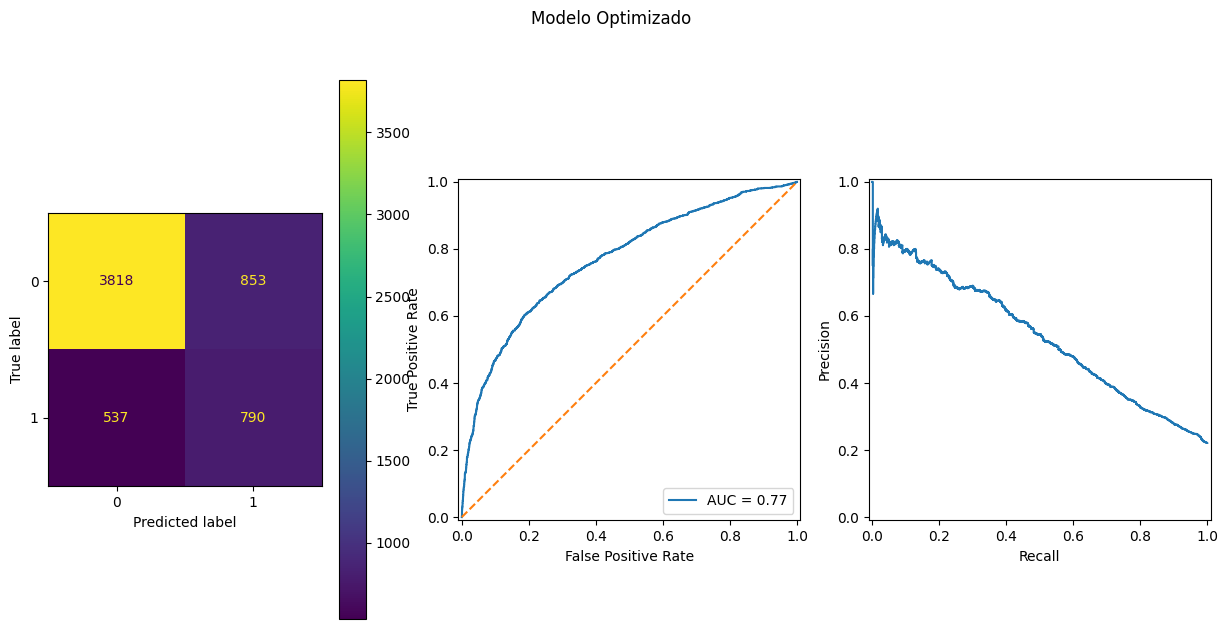

In [16]:
figure, axes = plt.subplots(1, 3, figsize = (15, 7))

plot_confusion_matrix(CM, axes = axes[0])
plot_roc_curve(y_test, y_scores, axes = axes[1])
plot_precision_recall_curve(y_test, y_scores, axes[2])

plt.suptitle('Modelo Optimizado')

## Evaluación de Thresholds

In [17]:
thresholds_test = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds_test:

    y_pred_test = (y_scores >= threshold).astype(int)

    CM, F1, ACCURACY, ROCAUC, RECALL, PRECISION, PR_AUC = score_modelo_no_lineal(
        y_test,
        y_pred_test,
        y_scores
    )

    tn, fp, fn, tp = CM.ravel()

    data = {

        "THRESHOLD": threshold,
        "F1": F1,
        "ACCURACY": ACCURACY,
        "PRECISION": PRECISION,
        "ROCAUC": ROCAUC,
        "RECALL": RECALL,
        "PR_AUC": PR_AUC,
        "tn" : tn,
        "fp" : fp,
        "fn" : fn,
        "tp" : tp
    }
    results.append(data)

threshold_test_results_df = pd.DataFrame(results)

threshold_test_results_df

,THRESHOLD,F1,ACCURACY,PRECISION,ROCAUC,RECALL,PR_AUC,tn,fp,fn,tp
0,0.10,0.362493,0.222407,0.221406,0.76807,0.999246,0.540807,8,4663,1,1326
1,0.15,0.364012,0.230410,0.222728,0.76807,0.995479,0.540807,61,4610,6,1321
2,0.20,0.375198,0.275925,0.231863,0.76807,0.982668,0.540807,351,4320,23,1304
3,0.25,0.398424,0.363621,0.251893,0.76807,0.952524,0.540807,917,3754,63,1264
4,0.30,0.429191,0.473158,0.282252,0.76807,0.895252,0.540807,1650,3021,139,1188
5,0.35,0.463007,0.587362,0.325107,0.76807,0.804069,0.540807,2456,2215,260,1067
6,0.40,0.499742,0.677226,0.380260,0.76807,0.728711,0.540807,3095,1576,360,967
7,0.45,0.521003,0.735745,0.434914,0.76807,0.649586,0.540807,3551,1120,465,862
8,0.50,0.531987,0.768256,0.480828,0.76807,0.595328,0.540807,3818,853,537,790
9,0.55,0.527166,0.785262,0.513958,0.76807,0.541070,0.540807,3992,679,609,718


## Ejercicio recreativo

A modo académico he optado por colar una pequeña matriz de costos, para revisar el impacto de como un modelo bajo circunstancias ficticias podria impactar al negocio. Para este proyecto podriaoms tomarlo meramente recreativo.

In [18]:
beneficio_tp = 5000
beneficio_tn = 1000
costo_fp = 1000
costo_fn = 10000

threshold_test_results_df["profit"] = (
    threshold_test_results_df["tp"] * beneficio_tp
    + threshold_test_results_df["tn"] * beneficio_tn
    - threshold_test_results_df["fp"] * costo_fp
    - threshold_test_results_df["fn"] * costo_fn
)

threshold_test_results_df = threshold_test_results_df.sort_values('profit', ascending= False)
threshold_test_results_df

,THRESHOLD,F1,ACCURACY,PRECISION,ROCAUC,RECALL,PR_AUC,tn,fp,fn,tp,profit
4,0.30,0.429191,0.473158,0.282252,0.76807,0.895252,0.540807,1650,3021,139,1188,3179000
5,0.35,0.463007,0.587362,0.325107,0.76807,0.804069,0.540807,2456,2215,260,1067,2976000
3,0.25,0.398424,0.363621,0.251893,0.76807,0.952524,0.540807,917,3754,63,1264,2853000
6,0.40,0.499742,0.677226,0.380260,0.76807,0.728711,0.540807,3095,1576,360,967,2754000
2,0.20,0.375198,0.275925,0.231863,0.76807,0.982668,0.540807,351,4320,23,1304,2321000
7,0.45,0.521003,0.735745,0.434914,0.76807,0.649586,0.540807,3551,1120,465,862,2091000
1,0.15,0.364012,0.230410,0.222728,0.76807,0.995479,0.540807,61,4610,6,1321,1996000
0,0.10,0.362493,0.222407,0.221406,0.76807,0.999246,0.540807,8,4663,1,1326,1965000
8,0.50,0.531987,0.768256,0.480828,0.76807,0.595328,0.540807,3818,853,537,790,1545000
9,0.55,0.527166,0.785262,0.513958,0.76807,0.541070,0.540807,3992,679,609,718,813000


In [20]:
saving_path = PROJECT_ROOT / 'models' / 'propposed_model'

save_model_joblib(saving_path, modelo_final, 'modelo_final')

In [21]:
import shap

/Users/marcoantoniogarciamartinez/Documents/Python Local/Entorno_DS/Python_Versions/3.11.15/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
  preprocessor = modelo_final.named_steps["preprocessor"]
  logistic_model = modelo_final.named_steps["model"]

  X_train_transformed = preprocessor.transform(X_train)
  X_test_transformed = preprocessor.transform(X_test)

  feature_names = preprocessor.get_feature_names_out()

  explainer = shap.LinearExplainer(
      logistic_model,
      X_train_transformed,
      feature_names=feature_names,
  )

  shap_values = explainer(X_test_transformed)

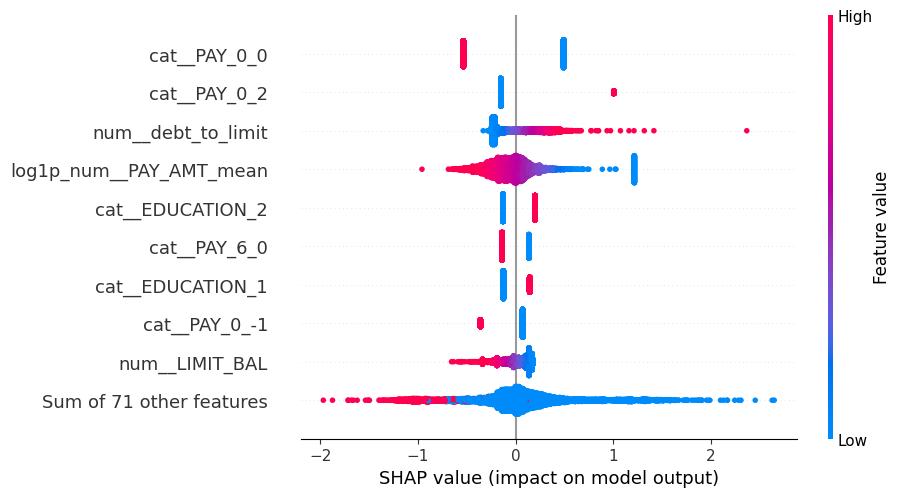

In [24]:
shap.plots.beeswarm(shap_values)

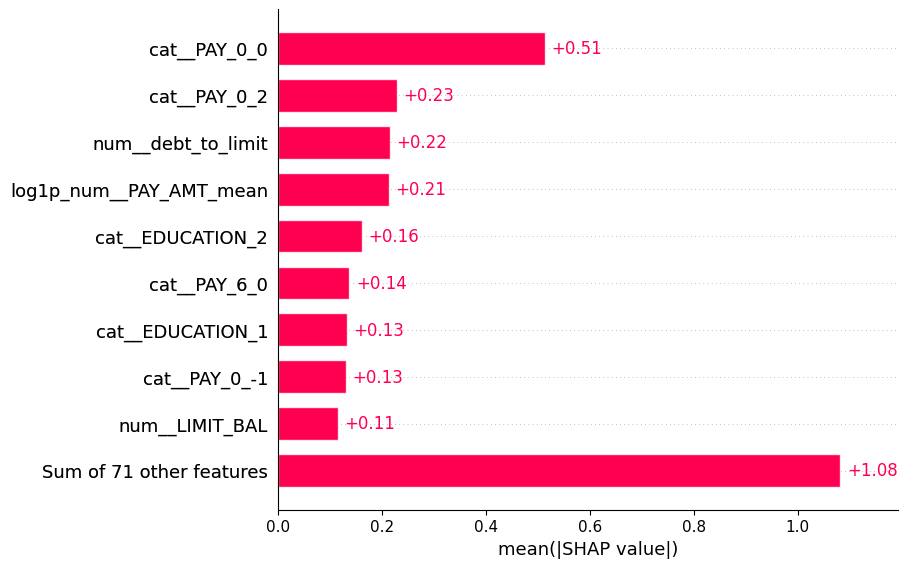

In [31]:
shap.plots.bar(shap_values)